# Tabulação Cruzada e Análise de Risco
**Objetivo:** investigar se a produção das linhas (`Unidades_Produzidas`) se relaciona com o nível de automação (`Nivel_Automacao`), categorizando a quantitativa em 2 classes, cruzando-a com a qualitativa, calculando a razão de prevalência e comparando as distribuições por boxplot.

In [60]:
#Importando as bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
#renomeando a planilha
arquivo='Eficiencia Operacional em Linhas de Producao.xlsx'

#lendo a planilha
df=pd.read_excel(arquivo)

df

,Nivel_Automacao,Tempo_Ciclo_s,Unidades_Produzidas
0,Alta,52.42,523
1,Baixa,43.03,643
2,Média,58.33,421
3,Baixa,55.95,495
4,Alta,36.54,832
...,...,...,...
995,Baixa,54.31,446
996,Média,49.62,601
997,Alta,51.04,597
998,Média,57.56,400


## 1. Categorização da variável quantitativa
**Variável escolhida:** `Unidades_Produzidas`, que mede o resultado do processo produtivo e, por isso, faz sentido relacioná-la ao nível de automação (`Nivel_Automacao`), já analisado nas sprints anteriores.

**Critério:** a **mediana** (601 unidades). Linhas com até 601 unidades são classificadas como **baixa producao**; acima disso, **alta producao**. A mediana divide os dados em grupos de tamanho praticamente igual (501 e 499 linhas) e não é afetada por valores extremos, o que torna a comparação equilibrada.

In [62]:
#Calculando a mediana de Unidades_Produzidas (critério de categorização)
mediana=df["Unidades_Produzidas"].median()
mediana

np.float64(601.0)

In [63]:
#Categorizando Unidades_Produzidas em 2 categorias: até a mediana = baixa producao; acima da mediana = alta producao
df["Producao_Categorizada"]=df["Unidades_Produzidas"].apply(lambda v: "baixa producao" if v<=mediana else "alta producao")

#Salvando a planilha categorizada
df.to_excel('Eficiencia Operacional em Linhas de Producao categorizado.xlsx',index=False)

#Tabela de frequências absoluta e relativa da variável categorizada
freq_abs=df["Producao_Categorizada"].value_counts()
freq_rel=(df["Producao_Categorizada"].value_counts(normalize=True)*100).round(1)

tab_freq=pd.DataFrame({"Frequência absoluta":freq_abs,"Frequência relativa (%)":freq_rel})
tab_freq.loc["Total"]=tab_freq.sum()
tab_freq["Frequência absoluta"]=tab_freq["Frequência absoluta"].astype(int)
tab_freq

,Frequência absoluta,Frequência relativa (%)
Producao_Categorizada,,
baixa producao,501,50.1
alta producao,499,49.9
Total,1000,100.0


In [64]:
#Definindo a ordem natural das categorias (a ordem alfabética colocaria Alta antes de Baixa)
df["Nivel_Automacao"]=df["Nivel_Automacao"].astype(pd.CategoricalDtype(categories=["Baixa","Média","Alta"],ordered=True))
df["Producao_Categorizada"]=df["Producao_Categorizada"].astype(pd.CategoricalDtype(categories=["baixa producao","alta producao"],ordered=True))

#Renomeando as variáveis que serão consideradas para a construção da tabela cruzada
var1= "Producao_Categorizada"
var2= "Nivel_Automacao"

#Exibindo as 5 primeiras observações do Data Set
df.head()

,Nivel_Automacao,Tempo_Ciclo_s,Unidades_Produzidas,Producao_Categorizada
0,Alta,52.42,523,baixa producao
1,Baixa,43.03,643,alta producao
2,Média,58.33,421,baixa producao
3,Baixa,55.95,495,baixa producao
4,Alta,36.54,832,alta producao


In [65]:
#Contruindo a tabela cruzada com frequências absolutas.
#A tabela cruzada é construída com uma coluna total e uma linha total escritas em inglês (ALL)

df_tabela_cruz=pd.crosstab(df[var1],df[var2],margins=True)

#Podemos renomear a coluna All para o Português:
df_tabela_cruz.rename(columns={'All': 'Total'}, inplace = True)
#Podemos renomear a linha All para o Português:
df_tabela_cruz.rename(index={'All': 'Total'}, inplace = True)

#Mostrando a Tabela cruzada
df_tabela_cruz

Nivel_Automacao,Baixa,Média,Alta,Total
Producao_Categorizada,,,,
baixa producao,143,230,128,501
alta producao,61,235,203,499
Total,204,465,331,1000


In [66]:
df_tabela_cruz_porcentagem = (pd.crosstab(df[var1], df[var2], margins = True, normalize= True)*100).round(1)
df_tabela_cruz_porcentagem.rename(index={'All': 'Total'}, inplace = True)
df_tabela_cruz_porcentagem.rename(columns={'All': 'Total'}, inplace = True)
df_tabela_cruz_porcentagem

Nivel_Automacao,Baixa,Média,Alta,Total
Producao_Categorizada,,,,
baixa producao,14.3,23.0,12.8,50.1
alta producao,6.1,23.5,20.3,49.9
Total,20.4,46.5,33.1,100.0


In [67]:
df_tabela_cruz_porcentagem_linhas = (pd.crosstab(df[var1], df[var2], margins = True, normalize='index')*100).round(1)
df_tabela_cruz_porcentagem_linhas.rename(index={'All': 'Total'}, inplace = True)
df_tabela_cruz_porcentagem_linhas

Nivel_Automacao,Baixa,Média,Alta
Producao_Categorizada,,,
baixa producao,28.5,45.9,25.5
alta producao,12.2,47.1,40.7
Total,20.4,46.5,33.1


In [68]:
df_tabela_cruz_porcentagem_colunas = (pd.crosstab(df[var1], df[var2], margins = True, normalize='columns')*100).round(1)
df_tabela_cruz_porcentagem_colunas.rename(columns={'All': 'Total'}, inplace = True)
df_tabela_cruz_porcentagem_colunas

Nivel_Automacao,Baixa,Média,Alta,Total
Producao_Categorizada,,,,
baixa producao,70.1,49.5,38.7,50.1
alta producao,29.9,50.5,61.3,49.9


*INTERPRETANDO OS RESULTADOS*

Com base nas tabelas geradas anteriormente e mostradas a seguir, podemos observar por exemplo, que:

*   **20,4%** das linhas de produção possuem nível de automação Baixa (tabela cruzada exibida com as frequências relativas (porcentagens) -df_tabela_cruz_porcentagem)
*   **50,1%** das linhas de produção têm baixa produção, isto é, produzem até 601 unidades (tabela cruzada exibida com as frequências relativas (porcentagens) -df_tabela_cruz_porcentagem)
*   Apenas **6,1%** das linhas combinam baixa automação com alta produção, enquanto **20,3%** combinam alta automação com alta produção (tabela cruzada exibida com as frequências relativas (porcentagens) -df_tabela_cruz_porcentagem)
*   **Dentre** as linhas com baixa produção, 45,9% têm automação Média (tabela cruzada exibida com as frequências relativas (porcentagens) por linhas -df_tabela_cruz_porcentagem_linhas)
*   **Dentre** as linhas com alta produção, 40,7% têm automação Alta e apenas 12,2% têm automação Baixa (tabela cruzada exibida com as frequências relativas (porcentagens) por linhas -df_tabela_cruz_porcentagem_linhas)
*   **70,1%** das linhas de automação Baixa têm baixa produção (tabela cruzada exibida com frequências relativas (porcentagens) por colunas -df_tabela_cruz_porcentagem_colunas)
*   **Dentre** as linhas de automação Alta, 61,3% têm alta produção, e nas de automação Média a divisão é quase meio a meio (49,5% e 50,5%) (tabela cruzada exibida com frequências relativas (porcentagens) por colunas -df_tabela_cruz_porcentagem_colunas)

In [69]:
df_tabela_cruz

Nivel_Automacao,Baixa,Média,Alta,Total
Producao_Categorizada,,,,
baixa producao,143,230,128,501
alta producao,61,235,203,499
Total,204,465,331,1000


In [70]:
df_tabela_cruz_porcentagem

Nivel_Automacao,Baixa,Média,Alta,Total
Producao_Categorizada,,,,
baixa producao,14.3,23.0,12.8,50.1
alta producao,6.1,23.5,20.3,49.9
Total,20.4,46.5,33.1,100.0


In [71]:
df_tabela_cruz_porcentagem_linhas

Nivel_Automacao,Baixa,Média,Alta
Producao_Categorizada,,,
baixa producao,28.5,45.9,25.5
alta producao,12.2,47.1,40.7
Total,20.4,46.5,33.1


In [72]:
df_tabela_cruz_porcentagem_colunas

Nivel_Automacao,Baixa,Média,Alta,Total
Producao_Categorizada,,,,
baixa producao,70.1,49.5,38.7,50.1
alta producao,29.9,50.5,61.3,49.9


**Interpretação:** 501 linhas (50,1%) ficaram em baixa produção e 499 (49,9%) em alta produção, uma divisão praticamente meio a meio, como esperado pelo critério da mediana.

In [73]:
#Tabela cruzada em frequências absolutas (sem margens)
tab=pd.crosstab(df[var1],df[var2])

#Exposição: Baixa automação | Referência: Alta automação | Desfecho: baixa producao
casos_exp=tab.loc["baixa producao","Baixa"]
total_exp=tab["Baixa"].sum()
casos_nexp=tab.loc["baixa producao","Alta"]
total_nexp=tab["Alta"].sum()

#Prevalência do desfecho em cada grupo
prev_exp=casos_exp/total_exp
prev_nexp=casos_nexp/total_nexp

tab_rp=pd.DataFrame({"Grupo":["Exposto (Baixa automação)","Referência (Alta automação)"],
              "Linhas com baixa produção":[casos_exp,casos_nexp],
              "Total de linhas":[total_exp,total_nexp],
              "Prevalência (%)":[round(prev_exp*100,2),round(prev_nexp*100,2)]})

#Razão de prevalência (RP) = prevalência nos expostos / prevalência nos não expostos
RP=prev_exp/prev_nexp
round(RP,2)

tab_rp

,Grupo,Linhas com baixa produção,Total de linhas,Prevalência (%)
0,Exposto (Baixa automação),143,204,70.10
1,Referência (Alta automação),128,331,38.67


## Análise de risco: razão de prevalência
**Desfecho:** baixa produção. **Exposição:** baixa automação. **Referência:** alta automação.

- Prevalência de baixa produção entre as linhas de baixa automação: 143/204 = **70,10%**
- Prevalência de baixa produção entre as linhas de alta automação: 128/331 = **38,67%**
- **Razão de prevalência (RP) = 70,10 / 38,67 ≈ 1,81**

**Interpretação:** a prevalência de baixa produção nas linhas de baixa automação é cerca de **1,81 vezes** (81% maior) a das linhas de alta automação. Como RP > 1, a baixa automação está associada a maior chance de baixa produção. Trata-se de uma associação observada nos dados, não de prova de causalidade.

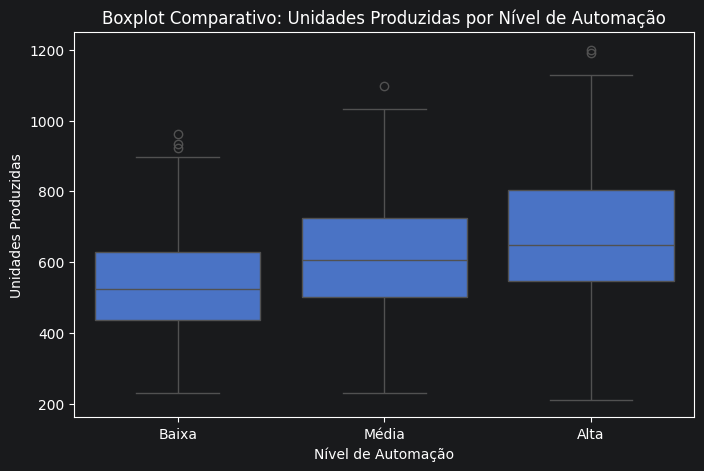

In [74]:
#Boxplot comparativo de Unidades_Produzidas por Nível de Automação
plt.figure(figsize=(8,5))
sns.boxplot(x="Nivel_Automacao",y="Unidades_Produzidas",data=df,order=["Baixa","Média","Alta"])
plt.title("Boxplot Comparativo: Unidades Produzidas por Nível de Automação")
plt.xlabel("Nível de Automação")
plt.ylabel("Unidades Produzidas")
plt.savefig("boxplot_comparativo.png",dpi=150,bbox_inches="tight")
plt.show()

## Boxplot comparativo
- A **mediana** da produção cresce com o nível de automação: 524,5 (Baixa), 606 (Média) e 647 (Alta), assim como a média (539,6; 618,1; 677,3).
- As caixas se **sobrepõem parcialmente** (Q1–Q3: 436–628,5; 502–724; 546–802,5): a automação aumenta a produção típica, mas não separa totalmente os grupos.
- A dispersão cresce com a automação (desvio padrão de 135,2; 158,9; 185,5), com coeficientes de variação parecidos (25,1%; 25,7%; 27,4%).
- Há poucos outliers, todos acima do limite superior (3, 1 e 2, respectivamente).

In [75]:
#Contagem de outliers por nível de automação (critério do boxplot: 1,5 x IQR)
grupo=df.groupby("Nivel_Automacao",observed=True)["Unidades_Produzidas"]
q1=grupo.transform(lambda s:s.quantile(0.25))
q3=grupo.transform(lambda s:s.quantile(0.75))
iqr=q3-q1
df["Outlier"]=(df["Unidades_Produzidas"]<q1-1.5*iqr)|(df["Unidades_Produzidas"]>q3+1.5*iqr)
df.groupby("Nivel_Automacao",observed=True)["Outlier"].sum()

Nivel_Automacao
Baixa    3
Média    1
Alta     2
Name: Outlier, dtype: int64

## Relação entre a variável categorizada e o nível de automação
As tabelas cruzadas, a razão de prevalência e o boxplot apontam o mesmo sentido: **quanto maior o nível de automação, maior a produção**. A proporção de linhas com baixa produção cai de 70,1% (Baixa) para 49,5% (Média) e 38,7% (Alta), e a baixa automação tem prevalência de baixa produção 1,81 vezes maior que a alta automação. Isso responde ao objetivo inicial e complementa a regressão: além do tempo de ciclo, a automação ajuda a explicar a produção. Como as caixas do boxplot se sobrepõem, a automação não é o único fator.